# Практическая работа 2.1. Моделирование тем и кластеризация документов

Повторение методички на датасете IMDB.


Моделирование тем — это процедура присвоения каждому документу одной или нескольких тем, которая, как правило, выполняется без учителя.

В данной работе используется метод латентного размещения Дирихле (`Latent Dirichlet Allocation`, `LDA`), который пытается находить группы слов, часто появляющихся вместе, и интерпретировать каждый документ как смесь нескольких тем.


In [1]:
from __future__ import annotations

import os
import re
import ssl
import tarfile
import urllib.request
from pathlib import Path

CACHE_DIR = Path(".cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(CACHE_DIR / "matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

DATA_DIR = Path(".data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(0)


In [2]:
from sklearn.datasets import load_files

DATASET_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
ARCHIVE_PATH = DATA_DIR / "aclImdb_v1.tar.gz"
DATASET_DIR = DATA_DIR / "aclImdb"


In [3]:
def get_feature_names(vectorizer) -> np.ndarray:
    """Возвращает имена признаков обученного текстового векторизатора.

    Parameters
    ----------
    vectorizer : Any
        Обученный объект `CountVectorizer`.

    Returns
    -------
    np.ndarray
        Массив текстовых признаков.
    """
    return np.array(vectorizer.get_feature_names_out())


def topic_words_df(
    components: np.ndarray,
    feature_names: np.ndarray,
    topics: np.ndarray | list[int],
    n_words: int = 10,
) -> pd.DataFrame:
    """Формирует таблицу наиболее важных слов для выбранных тем.

    Parameters
    ----------
    components : np.ndarray
        Матрица весов слов по темам.
    feature_names : np.ndarray
        Имена признаков.
    topics : np.ndarray | list[int]
        Индексы тем для вывода.
    n_words : int, default=10
        Количество слов на тему.

    Returns
    -------
    pd.DataFrame
        Таблица с описанием тем через их ключевые слова.
    """
    sorting = np.argsort(components, axis=1)[:, ::-1]
    rows = []
    for topic_idx in topics:
        rows.append(
            {
                "Тема": int(topic_idx),
                "Ключевые слова": ", ".join(feature_names[sorting[topic_idx, :n_words]]),
            }
        )
    return pd.DataFrame(rows)


def print_top_documents(
    texts: list[str],
    document_topics: np.ndarray,
    topic_idx: int,
    n_docs: int = 10,
    n_sentences: int = 2,
) -> None:
    """Печатает документы, наиболее связанные с указанной темой.

    Parameters
    ----------
    texts : list[str]
        Список исходных документов.
    document_topics : np.ndarray
        Матрица тем документов.
    topic_idx : int
        Индекс темы.
    n_docs : int, default=10
        Число выводимых документов.
    n_sentences : int, default=2
        Количество первых предложений для показа.

    Returns
    -------
    None
        Печатает фрагменты документов.
    """
    ranking = np.argsort(document_topics[:, topic_idx])[::-1]
    for doc_idx in ranking[:n_docs]:
        sentences = re.split(r"(?<=[.!?])\s+", texts[doc_idx].strip())
        excerpt = " ".join(sentences[:n_sentences])
        print(excerpt)
        print()


def plot_topic_weights(
    document_topics: np.ndarray,
    feature_names: np.ndarray,
    sorting: np.ndarray,
    title: str,
) -> None:
    """Строит диаграммы суммарных весов тем в корпусе.

    Parameters
    ----------
    document_topics : np.ndarray
        Матрица тем документов.
    feature_names : np.ndarray
        Имена признаков.
    sorting : np.ndarray
        Индексы слов, отсортированных по важности в темах.
    title : str
        Заголовок рисунка.

    Returns
    -------
    None
        Отрисовывает две горизонтальные столбчатые диаграммы.
    """
    fig, ax = plt.subplots(1, 2, figsize=(12, 12))
    topic_names = [
        f"{i:>2} " + " ".join(words)
        for i, words in enumerate(feature_names[sorting[:, :2]])
    ]
    topic_weights = np.sum(document_topics, axis=0)

    half = len(topic_names) // 2
    slices = [(0, half), (half, len(topic_names))]
    for col, (start, end) in enumerate(slices):
        ax[col].barh(np.arange(end - start), topic_weights[start:end])
        ax[col].set_yticks(np.arange(end - start))
        ax[col].set_yticklabels(topic_names[start:end], ha="left", va="top")
        ax[col].invert_yaxis()
        yax = ax[col].get_yaxis()
        yax.set_tick_params(pad=140)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## Загрузка данных IMDB


In [4]:
def download_imdb_dataset(
    dataset_url: str = DATASET_URL,
    archive_path: Path = ARCHIVE_PATH,
    dataset_dir: Path = DATASET_DIR,
) -> Path:
    """Скачивает и распаковывает набор IMDB при его отсутствии.

    Parameters
    ----------
    dataset_url : str, default=DATASET_URL
        Ссылка на архив с датасетом.
    archive_path : Path, default=ARCHIVE_PATH
        Путь к локальному архиву.
    dataset_dir : Path, default=DATASET_DIR
        Путь к распакованному датасету.

    Returns
    -------
    Path
        Каталог с данными `aclImdb`.
    """
    if dataset_dir.exists():
        return dataset_dir

    if not archive_path.exists():
        try:
            urllib.request.urlretrieve(dataset_url, archive_path)
        except Exception:
            ssl_context = ssl._create_unverified_context()
            with urllib.request.urlopen(dataset_url, context=ssl_context) as response:
                archive_path.write_bytes(response.read())

    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=archive_path.parent)

    return dataset_dir


In [5]:
def load_imdb_train(split_dir: Path) -> list[str]:
    """Загружает обучающие отзывы IMDB.

    Parameters
    ----------
    split_dir : Path
        Путь к каталогу `train`.

    Returns
    -------
    list[str]
        Список текстов отзывов.
    """
    dataset = load_files(
        str(split_dir),
        categories=["neg", "pos"],
        encoding="utf-8",
        decode_error="replace",
    )
    return [doc.replace("<br />", " ") for doc in dataset.data]


In [6]:
dataset_dir = download_imdb_dataset()
text_train = load_imdb_train(dataset_dir / "train")

print("Количество документов: {}".format(len(text_train)))
print("Пример документа:\n{}".format(text_train[0][:1200]))


Количество документов: 25000
Пример документа:
Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own/mutual world via coupled destruction.  It is not a perfect movie but given what money/time the filmmaker and actors had - it is a remarkable product. In terms of explaining the motives and actions of the two young suicide/murderers it is better than 'Elephant' - in terms of being a film that gets under our 'rationalistic' skin it is a far, far better film than almost anything you are likely to see.   Flawed but honest with a terrible honesty.


Для моделей неконтролируемого обучения, применяющихся к текстовым документам, часто бывает полезно удалить наиболее часто употребляемые слова. Удалим слова, которые появляются по крайней мере в `15%` документов, и ограничим словарь `10000` наиболее частыми словами.


In [7]:
vect = CountVectorizer(max_features=10000, max_df=0.15)
X = vect.fit_transform(text_train)

print("форма X: {}".format(X.shape))


форма X: (25000, 10000)


Построим модель, выделив `10` тем. Используем метод обучения `batch` и зададим `max_iter=25`.


In [8]:
lda = LatentDirichletAllocation(
    n_components=10,
    learning_method="batch",
    max_iter=25,
    random_state=0,
)
document_topics = lda.fit_transform(X)


In [9]:
lda.components_.shape


(10, 10000)

## Наиболее важные слова для 10 тем


In [10]:
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]
feature_names = get_feature_names(vect)

display(topic_words_df(lda.components_, feature_names, topics=np.arange(10), n_words=10))


,Тема,Ключевые слова
0,0,"between, young, family, real, performance, bea..."
1,1,"war, world, us, our, american, documentary, hi..."
2,2,"funny, worst, comedy, thing, guy, re, stupid, ..."
3,3,"show, series, episode, tv, episodes, shows, se..."
4,4,"didn, saw, am, thought, years, book, watched, ..."
5,5,"horror, action, effects, budget, nothing, orig..."
6,6,"kids, action, animation, game, fun, disney, ch..."
7,7,"cast, role, john, version, novel, both, direct..."
8,8,"performance, role, john, actor, oscar, cast, p..."
9,9,"house, woman, gets, killer, girl, wife, horror..."


Полученные `10` тем описывают корпус достаточно крупными блоками. На этом шаге обычно видны общие сюжетные линии и часто встречающиеся группы слов, однако границы между темами остаются довольно широкими.


Теперь построим еще одну модель, на этот раз выделив `100` тем.


In [11]:
lda100 = LatentDirichletAllocation(
    n_components=100,
    learning_method="batch",
    max_iter=25,
    random_state=0,
)
document_topics100 = lda100.fit_transform(X)


Вывод всех `100` тем был бы слишком громоздким, поэтому выберем лишь некоторые интересные и характерные темы.


In [12]:
topics = np.array([7, 16, 24, 25, 28, 36, 37, 45, 51, 53, 54, 63, 89, 97])
sorting = np.argsort(lda100.components_, axis=1)[:, ::-1]
feature_names = get_feature_names(vect)

display(topic_words_df(lda100.components_, feature_names, topics=topics, n_words=20))


,Тема,Ключевые слова
0,7,"thriller, suspense, horror, atmosphere, myster..."
1,16,"worst, awful, boring, horrible, stupid, thing,..."
2,24,"german, hitler, nazi, midnight, joe, germany, ..."
3,25,"car, gets, guy, around, down, kill, goes, kill..."
4,28,"beautiful, young, old, romantic, between, roma..."
5,36,"performance, role, actor, cast, play, actors, ..."
6,37,"excellent, highly, amazing, wonderful, truly, ..."
7,45,"music, song, songs, rock, band, soundtrack, si..."
8,51,"earth, space, planet, superman, alien, world, ..."
9,53,"scott, gary, streisand, star, hart, lundgren, ..."


При `100` темах модель выделяет более узкие и специфичные наборы слов. Это помогает точнее рассмотреть структуру корпуса, но интерпретация таких тем становится менее очевидной и требует дополнительной проверки по самим документам.


Посмотрим, какие документы были отнесены к теме `45`.


In [13]:
print_top_documents(text_train, document_topics100, topic_idx=45, n_docs=10, n_sentences=2)


I love this movie and never get tired of watching. The music in it is great.

I enjoyed Still Crazy more than any film I have seen in years. A successful band from the 70's decide to give it another try.

Hollywood Hotel was the last movie musical that Busby Berkeley directed for Warner Bros. His directing style had changed or evolved to the point that this film does not contain his signature overhead shots or huge production numbers with thousands of extras.

What happens to washed up rock-n-roll stars in the late 1990's? They launch a comeback / reunion tour.

As a big-time Prince fan of the last three to four years, I really can't believe I've only just got round to watching "Purple Rain". The brand new 2-disc anniversary Special Edition led me to buy it.

This film is worth seeing alone for Jared Harris' outstanding portrayal of John Lennon. It doesn't matter that Harris doesn't exactly resemble Lennon; his mannerisms, expressions, posture, accent and attitude are pure Lennon.

The

Просмотр документов нужен для проверки содержательной интерпретации темы. Если ключевые слова действительно отражают смысл темы, то и документы с наибольшим весом этой темы должны быть тематически близкими.


Еще один способ исследовать темы — посмотреть, какой вес получает каждая тема в целом, просуммировав `document_topics` по всем документам.


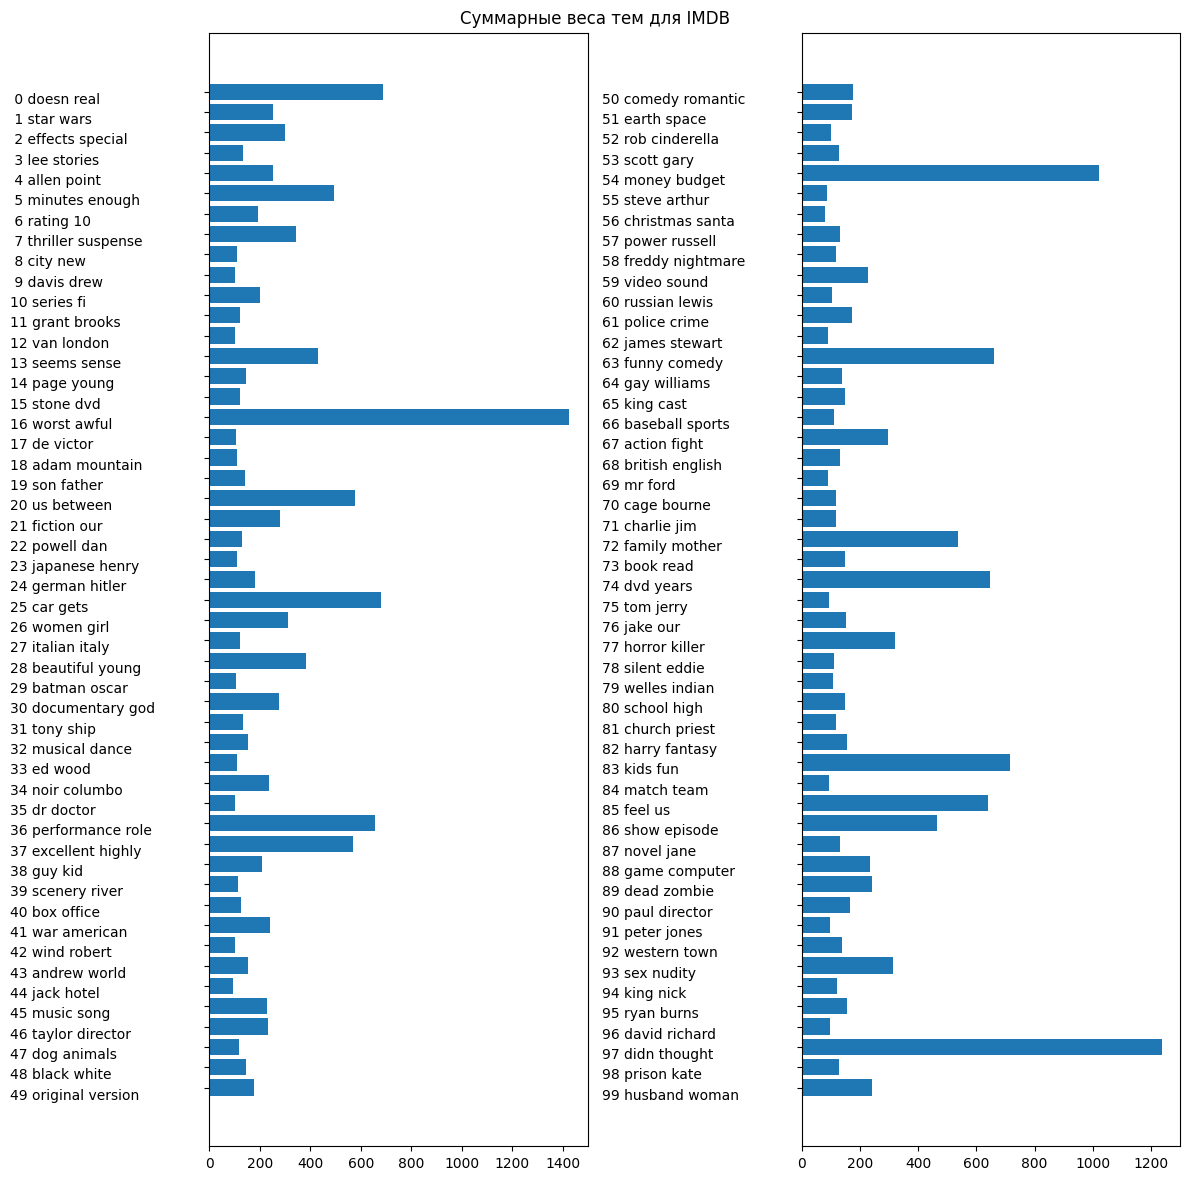

In [14]:
plot_topic_weights(
    document_topics100,
    feature_names,
    sorting,
    title="Суммарные веса тем для IMDB",
)


Суммарные веса показывают, какие темы наиболее заметны во всем корпусе IMDB. Чем выше столбец, тем больший вклад соответствующая тема вносит в описание всего набора отзывов.


## Вывод

На датасете IMDB были построены модели LDA с `10` и `100` темами. При малом числе тем они получаются более широкими и обобщенными, а при большом числе тем — более конкретными, но и более сложными для интерпретации.
